* By the time this project was developed, OpenAI had not yet released its integrated Web Search tool. That is why we are using Tavily here.

# Saying Hi to the AI

In [29]:
from dotenv import load_dotenv
load_dotenv()
import json
import time
from openai import OpenAI
from tavily import TavilyClient
import os
import httpx
from openai._base_client import DefaultHttpxClient
from openai import APITimeoutError, APIConnectionError, RateLimitError, APIStatusError
from typing import Any, Dict, Iterable, List, Optional

In [ ]:
OPENAI_API_KEY = os.environ.get("OPENAI_API_KEY", "")
TAVILY_API_KEY = os.environ.get("TAVILY_API_KEY", "")

In [31]:
# Creating OpenAI client with timeout and retries
httpx_client = DefaultHttpxClient(
    timeout=60.0,
    limits=httpx.Limits(max_keepalive_connections=10, max_connections=20),
)
client = OpenAI(api_key=OPENAI_API_KEY, http_client=httpx_client, max_retries=3)

In [32]:
# Tavily client (Optional)
tavily_client = TavilyClient(api_key=TAVILY_API_KEY)

In [33]:
MAX_TOOL_OUT = 8000  # avoiding giant tool outputs

def tavily_search(query: str) -> str:
    # print(f"[tavily_search] query={query!r}")
    out: Any = tavily_client.get_search_context(
        query,
        search_depth="advanced",
        max_tokens=8000,
    )
    if not isinstance(out, str):
        out = json.dumps(out, ensure_ascii=False)
    try:
        parsed = json.loads(out)
        if isinstance(parsed, list):
            out = "\n\n".join(str(x) for x in parsed)  # <-- making it readable
        elif isinstance(parsed, dict):
            out = json.dumps(parsed, ensure_ascii=False, indent=2)
    except Exception:
        pass
    if len(out) > MAX_TOOL_OUT:
        out = out[:MAX_TOOL_OUT]
    # print(f"[tavily_search] length={len(out)} chars")
    return out

In [34]:
# SYSTEM_PROMPT = (
# """
# Your function is to deeply search and analyze publicly available information to provide concise and direct answers in English based on data and information from the web.
# Do not ask confirmation questions; when necessary, search with the `tavily_search` tool and always return the answer in the requested format.
# If no answer format is requested, be brief and direct.
# If there is insufficient public evidence, simply answer: "Inconclusive".
# Do not repeat instructions or elaborate on the method.
# """
# ).strip()

SYSTEM_PROMPT = (
"""
Your function is to deeply search and analyze publicly available information to provide concise and direct answers in English based on data and information from the web.
Do not ask confirmation questions; when necessary, search with the `tavily_search` tool and always return the answer in the requested format.
If no answer format is requested, be brief and direct.
Do not repeat instructions or elaborate on the method.
"""
).strip()

In [35]:
TOOLS = [
    {
        "type": "function",
        "name": "tavily_search",
        "description": "It searches for up-to-date information on the web..",
        "parameters": {
            "type": "object",
            "properties": {
                "query": {"type": "string", "description": "Search query."}
            },
            "required": ["query"],
            "additionalProperties": False,
        },
        "strict": True,
    }
]

In [36]:
# ======================================================
# Helpers
# ======================================================

def _getattr_or_key(obj, attr, default=None):
    if hasattr(obj, attr):
        return getattr(obj, attr)
    if isinstance(obj, dict) and attr in obj:
        return obj[attr]
    return default


def extract_text_from_response(resp: Any) -> str:
    """Extracts assistant text from a Response object (robust to variants)."""
    # print("[extract_text_from_response] Starting text extraction...")
    final_chunks: List[str] = []
    output = _getattr_or_key(resp, "output", None)
    # print(
    #     f"[extract_text_from_response] output type={type(output)}, "
    #     f"len={len(output) if output else 0}"
    # )

    if not output:
        maybe_text = _getattr_or_key(resp, "output_text", None)
        if maybe_text:
            # print("[extract_text_from_response] using resp.output_text")
            return str(maybe_text)
        # print("[extract_text_from_response] empty output.")
        return ""

    for idx, item in enumerate(output):
        itype = _getattr_or_key(item, "type", None)
        irole = _getattr_or_key(item, "role", None)
        icontent = _getattr_or_key(item, "content", [])
        # print(
        #     f"  [item {idx}] type={itype!r} role={irole!r} "
        #     f"content_type={type(icontent)}"
        # )

        if itype == "message":
            if isinstance(icontent, (list, tuple)):
                # print(f"    [item {idx}] content len={len(icontent)}")
                for j, c in enumerate(icontent):
                    ctype = _getattr_or_key(c, "type", None)
                    if ctype in ("output_text", "text"):
                        text_piece = _getattr_or_key(c, "text", None)
                        # print(
                        #     f"      [content {j}] {ctype} "
                        #     f"len={len(text_piece) if text_piece else 0}"
                        # )
                        if text_piece:
                            final_chunks.append(text_piece)
                    # else:
                        # print(f"      [content {j}] different type: {ctype!r}")

    joined = "\n".join(final_chunks).strip()
    # print(f"[extract_text_from_response] Final text len={len(joined)}")
    return joined


def dedupe_blocks(text: str) -> str:
    """Light de-duplication to avoid repeated blocks in LLM outputs."""
    lines = [ln.rstrip() for ln in text.splitlines()]
    cleaned: List[str] = []
    prev: Optional[str] = None
    for ln in lines:
        if ln != prev:
            cleaned.append(ln)
        prev = ln

    s = "\n".join(cleaned).strip()  # <-- preserves paragraphs
    mid = len(s) // 2
    if len(s) > 200 and s[:mid] == s[mid:]:
        s = s[:mid].rstrip()
    return s

In [37]:
# ======================================================
# Retries + status polling
# ======================================================
TERMINAL = {"completed", "failed", "expired", "cancelled"}


def responses_create_with_retry(client: OpenAI, **kwargs):
    delays = [0, 1, 2, 4]
    last_err = None
    for i, d in enumerate(delays, 1):
        if d:
            # print(f"[responses_create_with_retry] {i} try after {d}s...")
            time.sleep(d)
        try:
            return client.responses.create(**kwargs)
        except (APITimeoutError, APIConnectionError) as e:
            # print(f"[responses_create_with_retry] network error/timeout: {e}")
            last_err = e
        except RateLimitError as e:
            # print(f"[responses_create_with_retry] rate limit: {e}")
            last_err = e
        except APIStatusError as e:
            # print(f"[responses_create_with_retry] status error: {e}")
            last_err = e
    raise last_err or RuntimeError("Error calling responses.create")


def wait_for_final_status(client: OpenAI, response_id: str, max_wait_s: int = 60, interval_s: float = 1.0):
    start = time.time()
    while True:
        resp = client.responses.retrieve(response_id=response_id)
        status = getattr(resp, "status", None)
        print(f"status={status}")
        out = getattr(resp, "output", None) or []
        has_calls = any(getattr(it, "type", None) == "function_call" for it in out)
        if status in TERMINAL or has_calls:
            return resp
        if time.time() - start > max_wait_s:
            print("timeout reached.")
            return resp
        time.sleep(interval_s)

In [ ]:
def run_with_tools_stateful(
    model: str,
    turn_input: list,                 # only the NEW messages for this turn (e.g.: [{"role":"user","content": "..."}])
    previous_response_id: Optional[str] = None,  # chains context
) -> tuple[str, Optional[str], Any]:
    # 1) first call of the turn
    resp = responses_create_with_retry(
        client,
        model=model,
        input=turn_input,
        tools=TOOLS,
        previous_response_id=previous_response_id,  # <— chains with the previous round
        parallel_tool_calls=True,
        max_tool_calls=4,
        # temperature=0.2,                             # <- control randomness
    )

    # 2) wait until it finishes or requests tools
    resp = wait_for_final_status(client, response_id=getattr(resp, "id", None), max_wait_s=60)

    while True:
        output = getattr(resp, "output", None) or []
        calls = []
        for item in output:
            if getattr(item, "type", None) == "function_call":
                fname = getattr(item, "name", None)
                args_raw = getattr(item, "arguments", None)
                call_id = getattr(item, "call_id", None)
                try:
                    args = args_raw if isinstance(args_raw, dict) else json.loads(args_raw or "{}")
                except Exception:
                    args = {}

                if fname == "tavily_search":
                    out = tavily_search(args.get("query", ""))
                    calls.append({"call_id": call_id, "output": out})

        if not calls:
            # No pending tool calls → extract final text and return the id to chain the NEXT turn
            answer = extract_text_from_response(resp) or getattr(resp, "output_text", "") or ""
            return dedupe_blocks(str(answer)), getattr(resp, "id", None), resp

        follow_up_items = [
            {"type": "function_call_output", "call_id": c["call_id"], "output": c["output"]}
            for c in calls
        ]

        # 3) Send tool outputs again LINKED to this response
        resp = responses_create_with_retry(
            client,
            model=model,
            input=follow_up_items,                           # <— only the new outputs
            tools=TOOLS,
            previous_response_id=getattr(resp, "id", None),  # <— ensures call_id linkage
            parallel_tool_calls=True,
            max_tool_calls=4,
            # temperature=0.2,                                 # <- control randomness
        )

        # 4) wait; a new call or the final text may come
        resp = wait_for_final_status(client, response_id=getattr(resp, "id", None), max_wait_s=60)


In [59]:
def generate_response(inputs_dict, model="gpt-5-nano"):
    result = {}
    previous_response_id: Optional[str] = None

    first = True
    for k, user_input in inputs_dict.items():
        print(f">>>> Processing key={k}")

        if first:
            turn_input = [
                {"role": "system", "content": SYSTEM_PROMPT},
                {"role": "user", "content": user_input},
            ]
            first = False
        else:
            turn_input = [{"role": "user", "content": user_input}]

        answer, previous_response_id, _resp = run_with_tools_stateful(
            model=model,
            turn_input=turn_input,
            previous_response_id=previous_response_id,  # <— real context chain
        )

        result[k] = answer or ""
        print(f">>>> RESULT for {k}: {result[k]}")

    return result

In [40]:
res = generate_response({"input": "Hi"})

>>>> Processing key=input
status=completed
>>>> RESULT for input: Hi! How can I help you today? You can ask me to search the web, summarize topics, answer questions, or brainstorm ideas.


In [41]:
res = generate_response({"input": "Give me the url for data of a certain star"})

>>>> Processing key=input
status=completed
>>>> RESULT for input: Please provide the star name (or coordinates).

If you want a quick URL template now, you can use SIMBAD:
- Template: http://simbad.u-strasbg.fr/simbad/sim-id?Ident=STAR_NAME
- Example: Sirius → http://simbad.u-strasbg.fr/simbad/sim-id?Ident=Sirius

Tell me the star you have in mind and I’ll give you the exact URL for its data.


# The Context Problem

LLMs have a limited time to generate a response even with sufficient timeout. Thus, it won't have time to analyze a big context, causing the model to give up on understanding the full context at some point in order to generate something back to you.

However, if you previously train the model (fine tuning) with your context, it won't need to spend time understanding it, because it is already trained. Then, after fine tuning, the model will already have the full context "in mind", generating a better response in time. 

# First Method: Supervised fine-tuning

Fine-tune models with example inputs and known good outputs for better results and efficiency.

1. Training data (that's the hard part)

In [ ]:
# Create a .jsonl file
{"messages":[{"role":"user","content":"What is the weather in San Francisco?"},{"role":"assistant","tool_calls":[{"id":"call_id","type":"function","function":{"name":"get_current_weather","arguments":"{\"location\": \"San Francisco, USA\", \"format\": \"celsius\"}"}}]}],"parallel_tool_calls":false,"tools":[{"type":"function","function":{"name":"get_current_weather","description":"Get the current weather","parameters":{"type":"object","properties":{"location":{"type":"string","description":"The city and country, eg. San Francisco, USA"},"format":{"type":"string","enum":["celsius","fahrenheit"]}},"required":["location","format"]}}}]}
{"messages":[{"role":"user","content":"What is the weather in Minneapolis?"},{"role":"assistant","tool_calls":[{"id":"call_id","type":"function","function":{"name":"get_current_weather","arguments":"{\"location\": \"Minneapolis, USA\", \"format\": \"celsius\"}"}}]}],"parallel_tool_calls":false,"tools":[{"type":"function","function":{"name":"get_current_weather","description":"Get the current weather","parameters":{"type":"object","properties":{"location":{"type":"string","description":"The city and country, eg. Minneapolis, USA"},"format":{"type":"string","enum":["celsius","fahrenheit"]}},"required":["location","format"]}}}]}
{"messages":[{"role":"user","content":"What is the weather in San Diego?"},{"role":"assistant","tool_calls":[{"id":"call_id","type":"function","function":{"name":"get_current_weather","arguments":"{\"location\": \"San Diego, USA\", \"format\": \"celsius\"}"}}]}],"parallel_tool_calls":false,"tools":[{"type":"function","function":{"name":"get_current_weather","description":"Get the current weather","parameters":{"type":"object","properties":{"location":{"type":"string","description":"The city and country, eg. San Diego, USA"},"format":{"type":"string","enum":["celsius","fahrenheit"]}},"required":["location","format"]}}}]}
{"messages":[{"role":"user","content":"What is the weather in Memphis?"},{"role":"assistant","tool_calls":[{"id":"call_id","type":"function","function":{"name":"get_current_weather","arguments":"{\"location\": \"Memphis, USA\", \"format\": \"celsius\"}"}}]}],"parallel_tool_calls":false,"tools":[{"type":"function","function":{"name":"get_current_weather","description":"Get the current weather","parameters":{"type":"object","properties":{"location":{"type":"string","description":"The city and country, eg. Memphis, USA"},"format":{"type":"string","enum":["celsius","fahrenheit"]}},"required":["location","format"]}}}]}
{"messages":[{"role":"user","content":"What is the weather in Atlanta?"},{"role":"assistant","tool_calls":[{"id":"call_id","type":"function","function":{"name":"get_current_weather","arguments":"{\"location\": \"Atlanta, USA\", \"format\": \"celsius\"}"}}]}],"parallel_tool_calls":false,"tools":[{"type":"function","function":{"name":"get_current_weather","description":"Get the current weather","parameters":{"type":"object","properties":{"location":{"type":"string","description":"The city and country, eg. Atlanta, USA"},"format":{"type":"string","enum":["celsius","fahrenheit"]}},"required":["location","format"]}}}]}
{"messages":[{"role":"user","content":"What is the weather in Sunnyvale?"},{"role":"assistant","tool_calls":[{"id":"call_id","type":"function","function":{"name":"get_current_weather","arguments":"{\"location\": \"Sunnyvale, USA\", \"format\": \"celsius\"}"}}]}],"parallel_tool_calls":false,"tools":[{"type":"function","function":{"name":"get_current_weather","description":"Get the current weather","parameters":{"type":"object","properties":{"location":{"type":"string","description":"The city and country, eg. Sunnyvale, USA"},"format":{"type":"string","enum":["celsius","fahrenheit"]}},"required":["location","format"]}}}]}
{"messages":[{"role":"user","content":"What is the weather in Chicago?"},{"role":"assistant","tool_calls":[{"id":"call_id","type":"function","function":{"name":"get_current_weather","arguments":"{\"location\": \"Chicago, USA\", \"format\": \"celsius\"}"}}]}],"parallel_tool_calls":false,"tools":[{"type":"function","function":{"name":"get_current_weather","description":"Get the current weather","parameters":{"type":"object","properties":{"location":{"type":"string","description":"The city and country, eg. Chicago, USA"},"format":{"type":"string","enum":["celsius","fahrenheit"]}},"required":["location","format"]}}}]}
{"messages":[{"role":"user","content":"What is the weather in Boston?"},{"role":"assistant","tool_calls":[{"id":"call_id","type":"function","function":{"name":"get_current_weather","arguments":"{\"location\": \"Boston, USA\", \"format\": \"celsius\"}"}}]}],"parallel_tool_calls":false,"tools":[{"type":"function","function":{"name":"get_current_weather","description":"Get the current weather","parameters":{"type":"object","properties":{"location":{"type":"string","description":"The city and country, eg. Boston, USA"},"format":{"type":"string","enum":["celsius","fahrenheit"]}},"required":["location","format"]}}}]}
{"messages":[{"role":"user","content":"What is the weather in Honolulu?"},{"role":"assistant","tool_calls":[{"id":"call_id","type":"function","function":{"name":"get_current_weather","arguments":"{\"location\": \"Honolulu, USA\", \"format\": \"celsius\"}"}}]}],"parallel_tool_calls":false,"tools":[{"type":"function","function":{"name":"get_current_weather","description":"Get the current weather","parameters":{"type":"object","properties":{"location":{"type":"string","description":"The city and country, eg. Honolulu, USA"},"format":{"type":"string","enum":["celsius","fahrenheit"]}},"required":["location","format"]}}}]}
{"messages":[{"role":"user","content":"What is the weather in San Antonio?"},{"role":"assistant","tool_calls":[{"id":"call_id","type":"function","function":{"name":"get_current_weather","arguments":"{\"location\": \"San Antonio, USA\", \"format\": \"celsius\"}"}}]}],"parallel_tool_calls":false,"tools":[{"type":"function","function":{"name":"get_current_weather","description":"Get the current weather","parameters":{"type":"object","properties":{"location":{"type":"string","description":"The city and country, eg. San Antonio, USA"},"format":{"type":"string","enum":["celsius","fahrenheit"]}},"required":["location","format"]}}}]}

In the example above, you are training the model to convert text into parameters for calling a function `get_weather`, your code should read the model response with the parameters (`run_with_tools_stateful`), run the function for the given parameters, and give the result back to the model.

PS: You can also train the model (using the training file) to deal with the function output by adding more messages to each training line.

2. Upload

In [ ]:
file_path = "./training_data.jsonl"

try:
    # Upload the file to OpenAI with the purpose 'fine-tune'
    training_file = client.files.create(
        file=open(file_path, "rb"),
        purpose="fine-tune"
    )

    print(f"File uploaded successfully. File ID: {training_file.id}")
    print(f"File status: {training_file.status}")

except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found.")
except Exception as e:
    print(f"An error occurred: {e}")

# The file ID is needed for the next step of creating the fine-tuning job
file_id = training_file.id

3. Start the fine-tuning job

In [ ]:
resp = client.fine_tuning.jobs.create(
    training_file=file_id,
    model="gpt-4o-mini-2024-07-18"
)
print(resp)

The starting of the process will tell you how long it is expected to take to train the model, but you can keep checking the status as below:

In [ ]:
print(client.fine_tuning.jobs.list())

4. Testing

Voilà, you trained the model! Let's test it.

In [ ]:
# Here, I'm giving the model an enormous context regarding the structure of a database
# with dozens of columns and instructing it to convert text to a SQL query
load_dotenv()
SYSTEM_PROMPT = os.environ.get("LARGE_CONTEXT")
assert SYSTEM_PROMPT, "LARGE_CONTEXT not loaded!"

Untrained model (gpt-5-nano by default):

In [ ]:
res = generate_response({"input": "I want to find the top 5 companies that contain the word "
"'technology' in any column (search across all columns)"})

>>>> Processing key=input
status=completed
>>>> RESULT for input: Here are ready-to-run options to get the top 5 companies whose data contains the word "technology" in any text column.

Assumptions
- You want the search to be case-insensitive.
- “Top 5” means the first 5 matches we find; I order by company name to make it deterministic. If you prefer a different order, tell me.
- The base table is base_filtrada and most relevant text columns include razao_social, nome_fantasia, logradouro, bairro, municipio, uf, pais, correio_eletronico, etc. I show a conservative set of columns you can extend.

Option A: Simple search across a fixed set of text columns (PostgreSQL)
SELECT DISTINCT
  cnpj,          -- or use razao_social if you prefer
  razao_social,
  nome_fantasia
FROM base_filtrada
WHERE LOWER(COALESCE(razao_social, '')) LIKE '%technology%'
   OR LOWER(COALESCE(nome_fantasia, '')) LIKE '%technology%'
   OR LOWER(COALESCE(logradouro, '')) LIKE '%technology%'
   OR LOWER(COALESCE(bair

Issues:

1. The query is not highlighted with ``` as required by the context;
2. The query only searches in 8 colomns, not ALL columns as requested by the user;
3. It suggests "I can tailor the exact query to your DB (PostgreSQL, MySQL, SQL Server)" while the context says that it is for a SQLite database in the FIRST sentence.

Trained model (gpt-4o-mini, older and cheaper model trained with 105 samples, about 1M characters):

In [49]:
# Now, I will be using almost the same context, but without the instructions on how the
# response should look like, just with the database structure (reducing about 20% of 
# the size of the context, which still pretty large)
load_dotenv()
SYSTEM_PROMPT = os.environ.get("LARGE_CONTEXT_TRAINED")
TRAINED_MODEL = os.environ.get("TRAINED_MODEL")
assert SYSTEM_PROMPT, "LARGE_CONTEXT_TRAINED not loaded!"
assert SYSTEM_PROMPT, "TRAINED_MODEL not loaded!"

In [ ]:
res = generate_response({"input": "I want to find the top 5 companies that contain the word "
"'technology' in any column (search across all columns)"}, model=TRAINED_MODEL)

>>>> Processing key=input
status=completed
>>>> RESULT for input: ```sql
SELECT *
FROM base_filtrada
WHERE LOWER(cnpj_basico) LIKE '%tecnologia%'
   OR LOWER(cnpj_ordem) LIKE '%tecnologia%'
   OR LOWER(cnpj_dv) LIKE '%tecnologia%'
   OR LOWER(matriz_filial) LIKE '%tecnologia%'
   OR LOWER(nome_fantasia) LIKE '%tecnologia%'
   OR LOWER(situacao_cadastral) LIKE '%tecnologia%'
   OR LOWER(data_situacao_cadastral) LIKE '%tecnologia%'
   OR LOWER(motivo_situacao_cadastral) LIKE '%tecnologia%'
   OR LOWER(nome_cidade_exterior) LIKE '%tecnologia%'
   OR LOWER(pais) LIKE '%tecnologia%'
   OR LOWER(data_inicio_atividades) LIKE '%tecnologia%'
   OR LOWER(cnae_fiscal) LIKE '%tecnologia%'
   OR LOWER(cnae_fiscal_secundaria) LIKE '%tecnologia%'
   OR LOWER(tipo_logradouro) LIKE '%tecnologia%'
   OR LOWER(logradouro) LIKE '%tecnologia%'
   OR LOWER(numero) LIKE '%tecnologia%'
   OR LOWER(complemento) LIKE '%tecnologia%'
   OR LOWER(bairro) LIKE '%tecnologia%'
   OR LOWER(cep) LIKE '%tecnologia%'
   

RESULT:
- ~6 times faster
- Much more accurate responses
- $5.60 of training cost
- ~$0.002 per execution (similar to untrained gpt-5-nano)

# Second Method: Reinforcement fine-tuning (o4-mini)

This is designed for unambiguous tasks based on complex reasoning. The training is based on generating multiple responses for a giving test where the responses are graded by a grading prompt. Then, after each test, the model should learn from the last grading and then generates more accurate responses as the model's goals is to maximize the grades. For this one, you will need:

### 1. Training file
Similarly to the supervised method, a .jsonl file with sample responses is required, but now you have to provide an explanation for why your sample response is correct.

In [ ]:
# Documentation example: a model that knows the policies of a fictional company
{
    "messages": [{
        "role": "user",
        "content": "Do you have a dedicated security team?"
    }],
    "compliant": "yes",
    "explanation": "A dedicated security team follows strict protocols for handling incidents."
}

### 2. Test file
It has the same structure as the training file, but the model won't see the expected responses and explanations. It will try to answer the test questions in multiple ways based on what it learned from the training file.

### 3. Grading prompt
Then, with the grading prompt and the expected answer/explanation, a grader model will analyze each generated response for the current test line and assign points (reward) for each one.

A grading prompt must contain context, examples, and instructions on how to grade on a given scale (usually 0 to 1).

In [ ]:
"""

# Overview

Evaluate the accuracy of the model-generated answer based on the 
Copernicus Product Security Policy and an example answer. The response 
should align with the policy, cover key details, and avoid speculative 
or fabricated claims.

Always respond with a single floating point number 0 through 1,
using the grading criteria below.

## Grading Criteria:
- **1.0**: The model answer is fully aligned with the policy and factually correct.
- **0.75**: The model answer is mostly correct but has minor omissions or slight rewording that does not change meaning.
- **0.5**: The model answer is partially correct but lacks key details or contains speculative statements.
- **0.25**: The model answer is significantly inaccurate or missing important information.
- **0.0**: The model answer is completely incorrect, hallucinates policy details, or is irrelevant.

## Copernicus Product Security Policy

### Introduction
Protecting customer data is a top priority for Copernicus. Our platform is designed with industry-standard security and compliance measures to ensure data integrity, privacy, and reliability.

### Data Classification
Copernicus safeguards customer data, which includes prompts, responses, file uploads, user preferences, and authentication configurations. Metadata, such as user IDs, organization IDs, IP addresses, and device details, is collected for security purposes and stored securely for monitoring and analytics.

### Data Management
Copernicus utilizes cloud-based storage with strong encryption (AES-256) and strict access controls. Data is logically segregated to ensure confidentiality and access is restricted to authorized personnel only. Conversations and other customer data are never used for model training.

### Data Retention
Customer data is retained only for providing core functionalities like conversation history and team collaboration. Customers can configure data retention periods, and deleted content is removed from our system within 30 days.

### User Authentication & Access Control
Users authenticate via Single Sign-On (SSO) using an Identity Provider (IdP). Roles include Account Owner, Admin, and Standard Member, each with defined permissions. User provisioning can be automated through SCIM integration.

### Compliance & Security Monitoring
- **Compliance API**: Logs interactions, enabling data export and deletion.
- **Audit Logging**: Ensures transparency for security audits.
- **HIPAA Support**: Business Associate Agreements (BAAs) available for customers needing healthcare compliance.
- **Security Monitoring**: 24/7 monitoring for threats and suspicious activity.
- **Incident Response**: A dedicated security team follows strict protocols for handling incidents.

### Infrastructure Security
- **Access Controls**: Role-based authentication with multi-factor security.
- **Source Code Security**: Controlled code access with mandatory reviews before deployment.
- **Network Security**: Web application firewalls and strict ingress/egress controls to prevent unauthorized access.
- **Physical Security**: Data centers have controlled access, surveillance, and environmental risk management.

### Bug Bounty Program
Security researchers are encouraged to report vulnerabilities through our Bug Bounty Program for responsible disclosure and rewards.

### Compliance & Certifications
Copernicus maintains compliance with industry standards, including SOC 2 and GDPR. Customers can access security reports and documentation via our Security Portal.

### Conclusion
Copernicus prioritizes security, privacy, and compliance. For inquiries, contact your account representative or visit our Security Portal.

## Examples

### Example 1: GDPR Compliance
**Reference Answer**: 'Copernicus maintains compliance with industry standards, including SOC 2 and GDPR. Customers can access security reports and documentation via our Security Portal.'

**Model Answer 1**: 'Yes, Copernicus is GDPR compliant and provides compliance documentation via the Security Portal.' 
**Score: 1.0** (fully correct)

**Model Answer 2**: 'Yes, Copernicus follows GDPR standards.'
**Score: 0.75** (mostly correct but lacks detail about compliance reports)

**Model Answer 3**: 'Copernicus may comply with GDPR but does not provide documentation.'
**Score: 0.5** (partially correct, speculative about compliance reports)

**Model Answer 4**: 'Copernicus does not follow GDPR standards.'
**Score: 0.0** (factually incorrect)

### Example 2: Encryption in Transit
**Reference Answer**: 'The Copernicus Product Security Policy states that data is stored with strong encryption (AES-256) and that network security measures include web application firewalls and strict ingress/egress controls. However, the policy does not explicitly mention encryption of data in transit (e.g., TLS encryption). A review is needed to confirm whether data transmission is encrypted.'

**Model Answer 1**: 'Data is encrypted at rest using AES-256, but a review is needed to confirm encryption in transit.'
**Score: 1.0** (fully correct)

**Model Answer 2**: 'Yes, Copernicus encrypts data in transit and at rest.'
**Score: 0.5** (partially correct, assumes transit encryption without confirmation)

**Model Answer 3**: 'All data is protected with encryption.'
**Score: 0.25** (vague and lacks clarity on encryption specifics)

**Model Answer 4**: 'Data is not encrypted in transit.'
**Score: 0.0** (factually incorrect)

Reference Answer: {{item.explanation}}
Model Answer: {{sample.output_json.explanation}}

"""

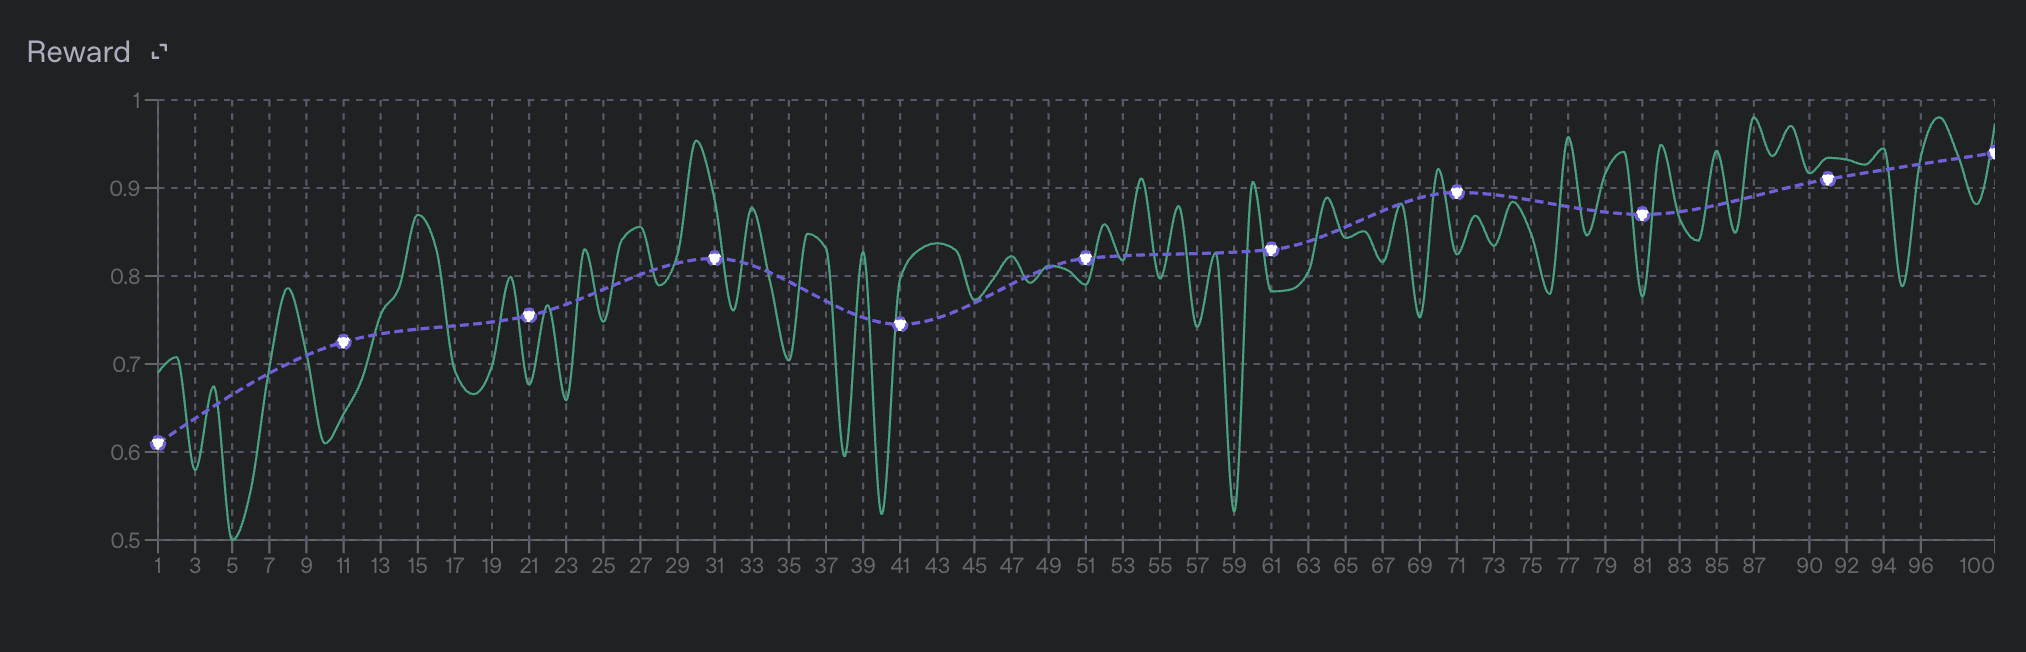

In [ ]:
TRAIN_PATH = "training.jsonl"
TEST_PATH = "test.jsonl"
GRADING_PROMPT_PATH = "grading_prompt.txt"


BASE_MODEL = "o4-mini-2025-04-16"

train_file = client.files.create(
    file=TRAIN_PATH,
    purpose="fine-tune",
)
test_file = client.files.create(
    file=TEST_PATH,
    purpose="fine-tune",
)

print("  - Training file id :", train_file.id)
print("  - Test file id     :", test_file.id)

In [ ]:
response_format = {
    "type": "json_schema",
    "json_schema": {
        "name": "security_assistant",
        "strict": True,
        "schema": {
            "type": "object",
            "properties": {
                "compliant": {"type": "string"},
                "explanation": {"type": "string"},
            },
            "required": ["compliant", "explanation"],
            "additionalProperties": False,
        },
    },
}

In [ ]:
with open(GRADING_PROMPT_PATH, "r", encoding="utf-8") as f:
    grading_prompt = json.load(f)

grader_config = {
        "type": "multi",
        "graders": {
          "explanation": {
            "name": "Explanation text grader",
            "type": "score_model",
            "input": [
              {
                "role": "user",
                "type": "message",
                "content": grading_prompt
              }
            ],
            "model": "gpt-4o-2024-08-06"
          },
          "compliant": {
            "name": "compliant",
            "type": "string_check",
            "reference": "{{item.compliant}}",
            "operation": "eq",
            "input": "{{sample.output_json.compliant}}"
          }
        },
        "calculate_output": "0.5 * compliant + 0.5 * explanation"
      }

In [ ]:
job = client.fine_tuning.jobs.create(
    training_file=train_file.id,
    validation_file=test_file.id,
    model=BASE_MODEL,
    method={
        "type": "reinforcement",
        "reinforcement": {
            "grader": grader_config,
            "response_format": response_format,
            "hyperparameters": {
                "reasoning_effort": "medium"
            },
        },
    },
    # (Optional)
    # suffix="meu-modelo-rft-v1",
    # metadata={"project": "security-review"},
)

print("  - Job id:", job.id)
print("  - Status inicial:", job.status)

In [ ]:
terminal_status = {"succeeded", "failed", "cancelled"}

while True:
    job = client.fine_tuning.jobs.retrieve(job.id)
    print(f"  - status atual: {job.status}")

    if job.status in terminal_status:
        break

    time.sleep(60)

if job.status != "succeeded":
    raise RuntimeError(f"Fine-tuning failed (status={job.status})")

In [ ]:
fine_tuned_model = job.fine_tuned_model
print(fine_tuned_model)

# Other Methods
## Direct preference optimization
"Fine-tune models for subjective decision-making by comparing model outputs."
## Vision fine-tuning
"Fine-tune models for better image understanding."

# Links
If you want to try OpenAI API:
- https://platform.openai.com/docs/quickstart

To learn more about every fine-tuning method mentioned here, see the OpenAI API official documentation for fine tuning:
- https://platform.openai.com/docs/guides/model-optimization
- https://platform.openai.com/docs/guides/supervised-fine-tuning
- https://platform.openai.com/docs/guides/reinforcement-fine-tuning
- https://platform.openai.com/docs/guides/reinforcement-fine-tuning
- https://platform.openai.com/docs/guides/reinforcement-fine-tuning

If you want to explore tavily:
- https://www.tavily.com

https://github.com/Vinicius-FR/OpenAI-Fine-Tuning-Introduction